In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp
from scipy.stats import binomtest
import warnings
import seaborn as sns
%matplotlib inline
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from collections import Counter

In [5]:
heart = pd.read_csv("Heart_disease_cleveland_new.csv") 
heart.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [6]:
heart['heart_disease'] = heart['target'].map({'presence': 1, 'absence': 0})
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,heart_disease
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0,NaN
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1,NaN
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1,NaN
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0,NaN
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0,NaN


In [7]:
# Check data quality
print("Data Quality Check:")
print(f"Total rows: {len(heart)}")
print(f"Missing cholesterol values: {heart['chol'].isna().sum()}")
print(f"\nFirst few rows of target column:\n{heart['target'].head(10)}")
print(f"\nFirst few rows of heart_disease column:\n{heart['heart_disease'].head(10)}")
print(f"\nUnique values in heart_disease:\n{heart['heart_disease'].unique()}")
print(f"\nData types:\n{heart.dtypes}")
print(f"\nTarget distribution:\n{heart['heart_disease'].value_counts()}")
print(f"\nValue counts with NaN:\n{heart['heart_disease'].value_counts(dropna=False)}")

Data Quality Check:
Total rows: 303
Missing cholesterol values: 0

First few rows of target column:
0    0
1    1
2    1
3    0
4    0
5    0
6    1
7    0
8    1
9    1
Name: target, dtype: int64

First few rows of heart_disease column:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: heart_disease, dtype: float64

Unique values in heart_disease:
[nan]

Data types:
age                int64
sex                int64
cp                 int64
trestbps           int64
chol               int64
fbs                int64
restecg            int64
thalach            int64
exang              int64
oldpeak          float64
slope              int64
ca                 int64
thal               int64
target             int64
heart_disease    float64
dtype: object

Target distribution:
Series([], Name: count, dtype: int64)

Value counts with NaN:
heart_disease
NaN    303
Name: count, dtype: int64


In [8]:
yes_hd = heart[heart.heart_disease == 1]
no_hd = heart[heart.heart_disease == 0]

print(f"Rows with heart_disease == 1: {len(yes_hd)}")
print(f"Rows with heart_disease == 0: {len(no_hd)}")
print(f"\nDebug - Checking filter for value 1:")
print(f"heart['heart_disease'] == 1 returns:\n{(heart['heart_disease'] == 1).sum()} True values")

# Try alternative approach with NaN handling
if len(yes_hd) == 0:
    print("\nFilter returned empty! Trying with fillna...")
    yes_hd = heart[heart['heart_disease'].fillna(-1) == 1]
    print(f"After fillna: {len(yes_hd)} rows")

chol_hd = yes_hd['chol'].dropna() if len(yes_hd) > 0 else pd.Series([], dtype=float)
print(f"\nNumber of valid cholesterol values: {len(chol_hd)}")
if len(chol_hd) > 0:
    print("Mean cholesterol level for patients:", np.mean(chol_hd))
else:
    print("No valid cholesterol values to compute mean")

Rows with heart_disease == 1: 0
Rows with heart_disease == 0: 0

Debug - Checking filter for value 1:
heart['heart_disease'] == 1 returns:
0 True values

Filter returned empty! Trying with fillna...
After fillna: 0 rows

Number of valid cholesterol values: 0
No valid cholesterol values to compute mean


In [9]:
p_threshold = 0.05
tstat, pval_two_sided = ttest_1samp(chol_hd, 240)
pval_one_sided = pval_two_sided / 2
print("\nMean cholesterol level for patients:", np.mean(chol_hd))
print("t-statistic:", tstat)
print("Two-sided p-value:", pval_two_sided)
print("One-sided p-value:", pval_one_sided)
if pval_two_sided < p_threshold:
    print(f"Result: Significant (p < {p_threshold})")
else:
    print(f"Result: Not significant (p >= {p_threshold})")


Mean cholesterol level for patients: nan
t-statistic: nan
Two-sided p-value: nan
One-sided p-value: nan
Result: Not significant (p >= 0.05)


C:\Users\apexf\AppData\Local\Temp\ipykernel_2664\429910221.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  tstat, pval_two_sided = ttest_1samp(chol_hd, 240)


In [10]:
chol_no_hd = no_hd['chol'].dropna()
print(f"Number of valid cholesterol values (no HD): {len(chol_no_hd)}")
tstat, pval_two_sided = ttest_1samp(chol_no_hd, 240)
pval_one_sided = pval_two_sided / 2
print("\nMean cholesterol level for patients without heart disease:", np.mean(chol_no_hd))
print("t-statistic:", tstat)
print("One-sided p-value:", pval_one_sided)

Number of valid cholesterol values (no HD): 0

Mean cholesterol level for patients without heart disease: nan
t-statistic: nan
One-sided p-value: nan


C:\Users\apexf\AppData\Local\Temp\ipykernel_2664\518740217.py:3: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  tstat, pval_two_sided = ttest_1samp(chol_no_hd, 240)


In [11]:
num_patients = len(heart)
print("\nNumber Of Rows:",num_patients)

num_highfbs_patients = heart[heart['fbs'] == 1].shape[0]
print("Number of patients with fasting blood sugar > 120 mg/dl:", num_highfbs_patients)

expected_num = 0.08 * heart.shape[0]
print("Expected number of patients with diabetes (8%):", expected_num)



Number Of Rows: 303
Number of patients with fasting blood sugar > 120 mg/dl: 45
Expected number of patients with diabetes (8%): 24.240000000000002


In [12]:
n = heart.shape[0]
test_result = binomtest(num_highfbs_patients, n, p=0.08, alternative='greater')
print("One-sided p-value:", test_result)
heart.info()
print("\nMissing values:\n", heart.isnull().sum())


One-sided p-value: BinomTestResult(k=45, n=303, alternative='greater', statistic=0.1485148514851485, pvalue=4.689471951448875e-05)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            303 non-null    int64  
 1   sex            303 non-null    int64  
 2   cp             303 non-null    int64  
 3   trestbps       303 non-null    int64  
 4   chol           303 non-null    int64  
 5   fbs            303 non-null    int64  
 6   restecg        303 non-null    int64  
 7   thalach        303 non-null    int64  
 8   exang          303 non-null    int64  
 9   oldpeak        303 non-null    float64
 10  slope          303 non-null    int64  
 11  ca             303 non-null    int64  
 12  thal           303 non-null    int64  
 13  target         303 non-null    int64  
 14  heart_disease  0 non-null      float64
dtypes: float64(

In [13]:
print("MEAN values of dataset:\n")
print(heart.mean(numeric_only=True))

MEAN values of dataset:

age               54.438944
sex                0.679868
cp                 2.158416
trestbps         131.689769
chol             246.693069
fbs                0.148515
restecg            0.990099
thalach          149.607261
exang              0.326733
oldpeak            1.039604
slope              0.600660
ca                 0.663366
thal               1.831683
target             0.458746
heart_disease           NaN
dtype: float64


ValueError: List of boxplot statistics and `positions` values must have same the length

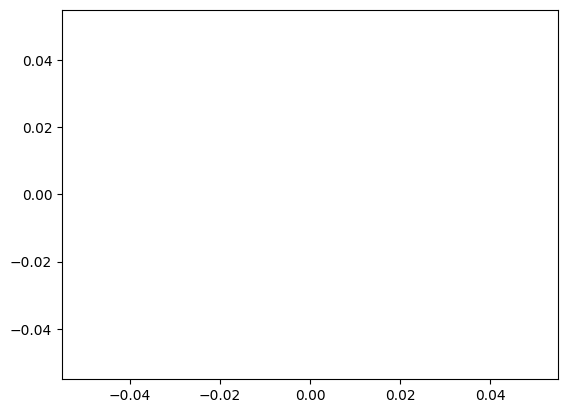

In [14]:
sns.boxplot(x=heart.heart_disease, y=heart.thalach)
plt.show()

# save `thalach` for hd patients and non-hd patients
thalach_hd = heart.thalach[heart.heart_disease == 'presence']
thalach_no_hd = heart.thalach[heart.heart_disease == 'absence']

# calculate and print mean difference
mean_diff = np.mean(thalach_no_hd) - np.mean(thalach_hd)
print('`thalach` mean Difference: ', mean_diff)

# calculate and print median difference
med_diff = np.median(thalach_no_hd) - np.median(thalach_hd)
print('`thalach` median Difference: ', med_diff)

# run two-sample t-test
from scipy.stats import ttest_ind
tstat, pval = ttest_ind(thalach_hd, thalach_no_hd)
print('p-value for `thalach` two-sample t-test: ', pval)

# investigating other quantitative variables
#age
plt.clf()
sns.boxplot(x=heart.heart_disease, y=heart.age)
plt.show()
age_hd = heart.age[heart.heart_disease == 'presence']
age_no_hd = heart.age[heart.heart_disease == 'absence']
mean_diff = np.mean(age_hd) - np.mean(age_no_hd)
print('`age` mean Difference: ', mean_diff)
med_diff = np.median(age_hd) - np.median(age_no_hd)
print('`age` median Difference: ', med_diff)
tstat, pval = ttest_ind(age_hd, age_no_hd)
print('p-value for `age` two-sample t-test: ', pval)

#trestbps
plt.clf()
sns.boxplot(x=heart.heart_disease, y=heart.trestbps)
plt.show()
trestbps_hd = heart.trestbps[heart.heart_disease == 'presence']
trestbps_no_hd = heart.trestbps[heart.heart_disease == 'absence']
mean_diff = np.mean(trestbps_hd) - np.mean(trestbps_no_hd)
print('`trestbps` mean Difference: ', mean_diff)
med_diff = np.median(trestbps_hd) - np.median(trestbps_no_hd)
print('`trestbps` median Difference: ', med_diff)
tstat, pval = ttest_ind(trestbps_hd, trestbps_no_hd)
print('p-value for `trestbps` two-sample t-test: ', pval)

#chol
plt.clf()
sns.boxplot(x=heart.heart_disease, y=heart.chol)
plt.show()
chol_hd = heart.chol[heart.heart_disease == 'presence']
chol_no_hd = heart.chol[heart.heart_disease == 'absence']
mean_diff = np.mean(chol_hd) - np.mean(chol_no_hd)
print('`chol` mean Difference: ', mean_diff)
med_diff = np.median(chol_hd) - np.median(chol_no_hd)
print('`chol` median Difference: ', med_diff)
tstat, pval = ttest_ind(chol_hd, chol_no_hd)
print('p-value for `chol` two-sample t-test: ', pval)

# box plot of `thalach` based on `cp`
plt.clf()
sns.boxplot(x=heart.cp, y=heart.thalach)
plt.show()

# save `thalach` based on `cp`
thalach_typical = heart.thalach[heart.cp == 'typical angina']
thalach_asymptom = heart.thalach[heart.cp == 'asymptomatic']
thalach_nonangin = heart.thalach[heart.cp == 'non-anginal pain']
thalach_atypical = heart.thalach[heart.cp == 'atypical angina']

# run ANOVA
from scipy.stats import f_oneway
Fstat, pval = f_oneway(thalach_typical, thalach_asymptom, thalach_nonangin, thalach_atypical)
print('p-value for ANOVA: ', pval)

# run Tukey's range test
from statsmodels.stats.multicomp import pairwise_tukeyhsd
output = pairwise_tukeyhsd(heart.thalach, heart.cp)
print(output)

# contingency table of heart disease vs cp
Xtab = pd.crosstab(heart.cp, heart.heart_disease)
print(Xtab)

# run chi-square test
from scipy.stats import chi2_contingency
chi2, pval, dof, exp = chi2_contingency(Xtab)
print('p-value for chi-square test: ', pval)


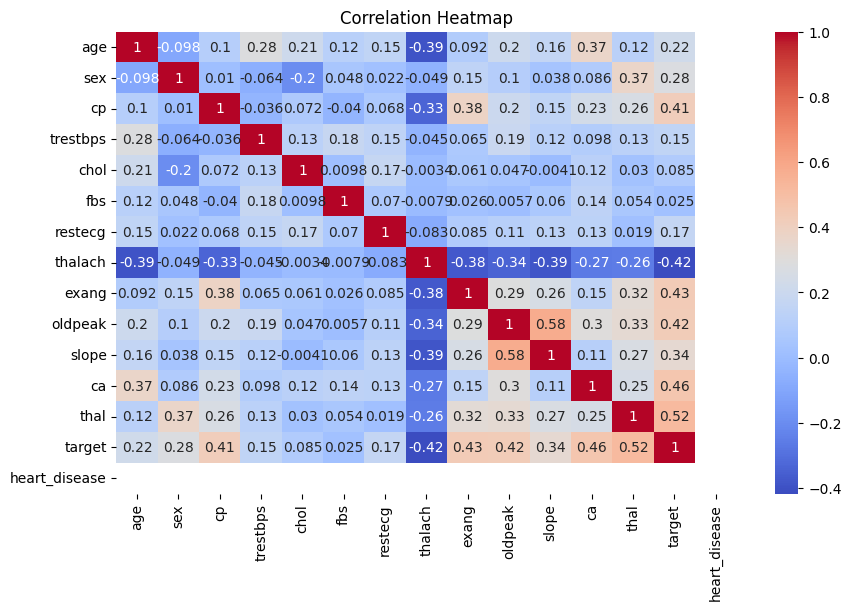

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(heart.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

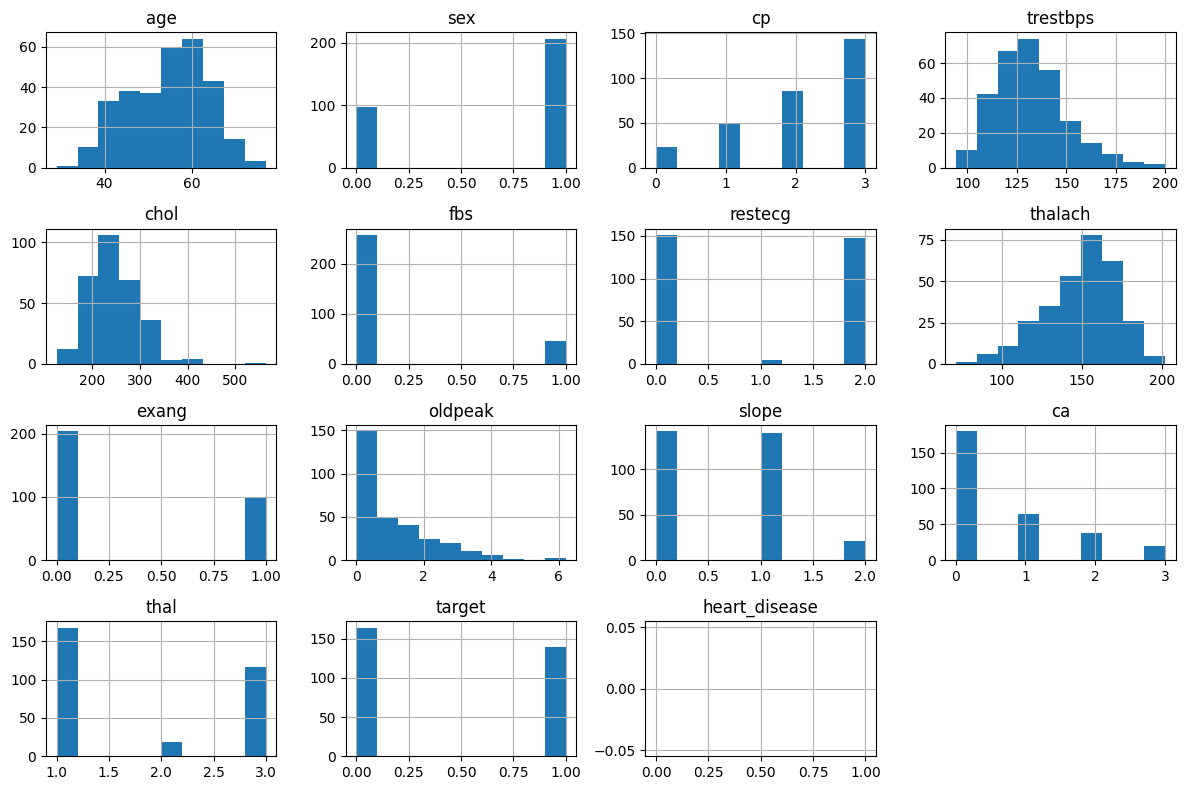

In [ ]:
heart.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

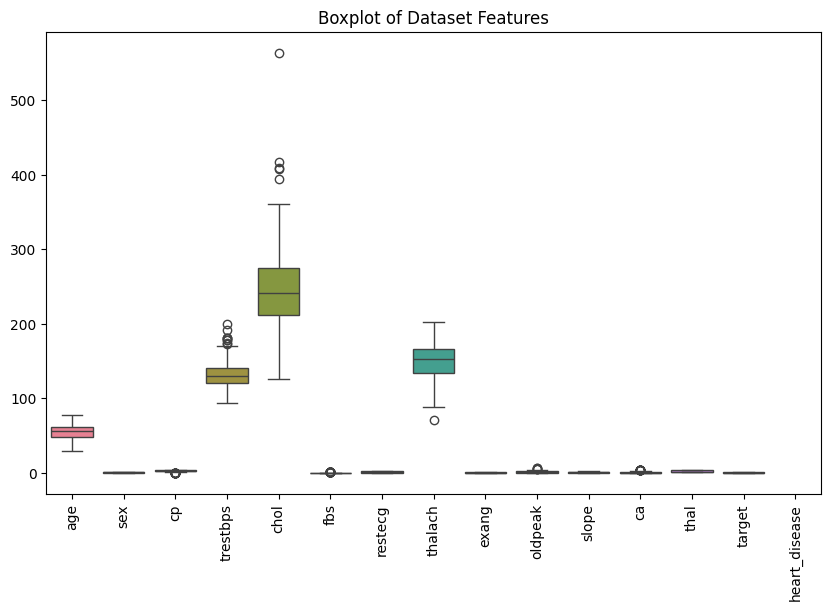

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=heart)
plt.title("Boxplot of Dataset Features")
plt.xticks(rotation=90)
plt.show()

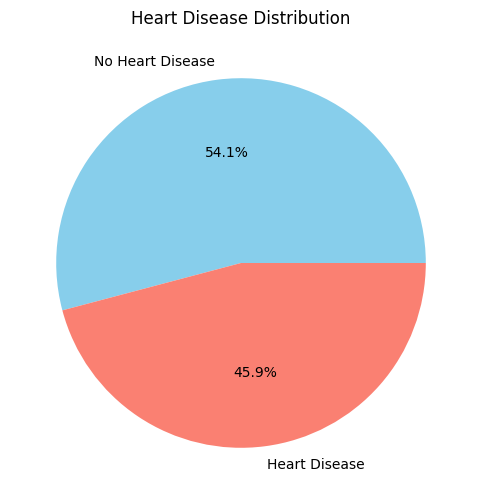

In [ ]:
target_counts = heart['target'].value_counts()
labels = ['No Heart Disease','Heart Disease']
colors = ['skyblue','salmon']

plt.figure(figsize=(6,6))
plt.pie(target_counts, labels=labels, autopct='%1.1f%%', colors=colors)
plt.title("Heart Disease Distribution")
plt.show()


In [ ]:
X = heart.drop('target', axis=1)
y = heart['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print("Train set class distribution:", Counter(y_train))
print("Test set class distribution:", Counter(y_test))

Train set class distribution: Counter({0: 129, 1: 113})
Test set class distribution: Counter({0: 35, 1: 26})


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

C:\Users\apexf\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\apexf\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\apexf\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_conf = confusion_matrix(y_test, lr_pred)
lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Regression Confusion Matrix:\n", lr_conf)
print("\nLogistic Regression Accuracy:", lr_acc*100, "%\n")
print("Classification Report:\n", classification_report(y_test, lr_pred))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_conf = confusion_matrix(y_test, rf_pred)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Confusion Matrix:\n", rf_conf)
print("\nRandom Forest Accuracy:", rf_acc*100, "%\n")
print("Classification Report:\n", classification_report(y_test, rf_pred))

Random Forest Confusion Matrix:
 [[30  5]
 [ 9 17]]

Random Forest Accuracy: 77.04918032786885 %

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.86      0.81        35
           1       0.77      0.65      0.71        26

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.76        61
weighted avg       0.77      0.77      0.77        61



In [ ]:
model_compare = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy (%)': [lr_acc*100, rf_acc*100]
})
print(model_compare)

                 Model  Accuracy (%)
0  Logistic Regression     78.688525
1        Random Forest     77.049180


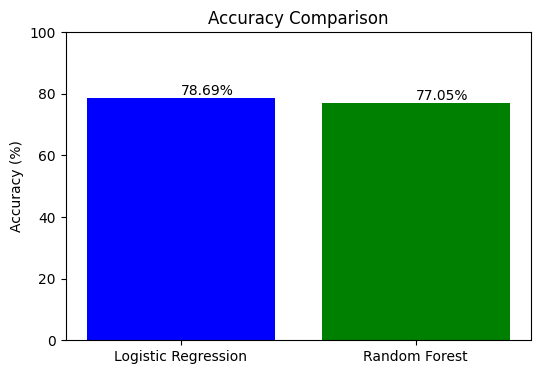

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(model_compare['Model'], model_compare['Accuracy (%)'], color=['blue','green'])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0,100)
for idx, val in enumerate(model_compare['Accuracy (%)']):
    plt.text(idx, val+1, f"{val:.2f}%")
plt.show()

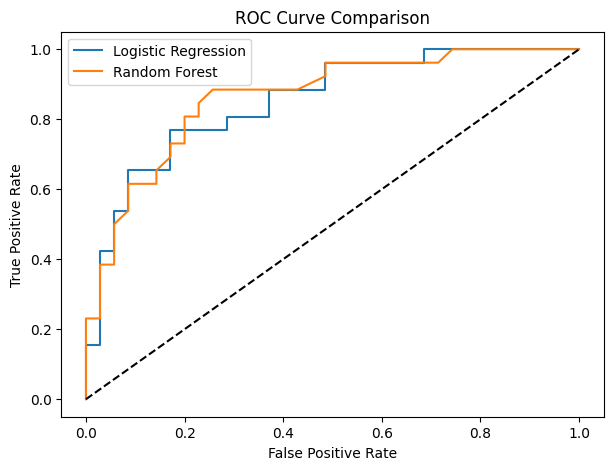

In [ ]:
lr_probs = lr.predict_proba(X_test)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
plt.figure(figsize=(7,5))
plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
heart.corr()['target'].sort_values(ascending=False)

target      1.000000
thal        0.515894
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64

In [ ]:
corr_with_target = heart.corr()['target'].sort_values(ascending=False)
print("Correlation of each feature with target:\n")
print(corr_with_target)

Correlation of each feature with target:

target      1.000000
thal        0.515894
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


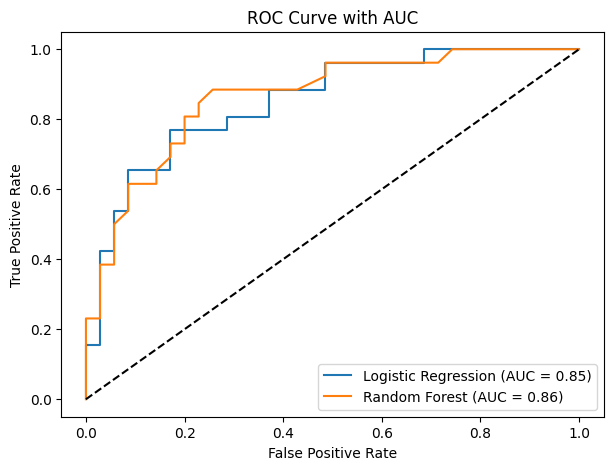

In [ ]:
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
plt.figure(figsize=(7,5))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve with AUC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
warnings.filterwarnings("ignore", message="X does not have valid feature names")
new_data = np.array([[63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]])
new_data_scaled = scaler.transform(new_data)
prediction = rf.predict(new_data_scaled)[0]
if prediction == 1:
    print("High chance of Heart Attack")
else:
    print("Low chance of Heart Attack")

Low chance of Heart Attack


In [ ]:
prob = rf.predict_proba(new_data_scaled)[0][1]
print(f"Risk Probability: {prob*100:.2f}%")


Risk Probability: 23.00%


2025-11-05 23:05:56.168 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-05 23:05:56.606 
  command:

    streamlit run c:\Directory\Anaconda\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-11-05 23:05:56.607 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-05 23:05:56.608 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-05 23:05:56.609 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-05 23:05:56.610 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-05 23:05:56.643 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-05 23:05:56.644 Thread 'MainThread': missi